<a href="https://colab.research.google.com/github/Bhumisti2006/AI-powered-Early-Warning-System-for-Tea-Gardens-/blob/main/ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression


In [ ]:
df = pd.read_csv("/content/DailyDelhiClimateTest.csv")


In [ ]:
df.head(10)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333
5,2017-01-06,19.318182,79.318182,8.681818,1011.772727
6,2017-01-07,14.708333,95.833333,10.041667,1011.375000
7,2017-01-08,15.684211,83.526316,1.950000,1015.550000
8,2017-01-09,14.571429,80.809524,6.542857,1015.952381
9,2017-01-10,12.111111,71.944444,9.361111,1016.888889


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.head(5)

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [ ]:
df.isnull().sum()


,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


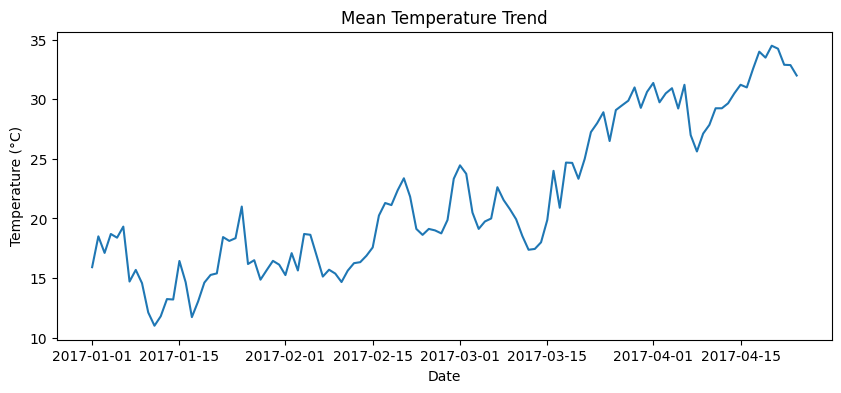

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['date'], df['meantemp'])
plt.title("Mean Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()



In [ ]:
# Rolling averages (plant stress depends on sustained exposure)
df['temp_7day_avg'] = df['meantemp'].rolling(7).mean()
df['humidity_7day_avg'] = df['humidity'].rolling(7).mean()

# Stress indicators
df['heat_stress'] = np.where(df['meantemp'] > 32, 1, 0)
df['dry_stress'] = np.where(df['humidity'] < 40, 1, 0)
df['low_pressure'] = np.where(df['meanpressure'] < 1000, 1, 0)

# Remove NaN caused by rolling window
df.dropna(inplace=True)


In [ ]:
def classify_stress(row):
    if row['meantemp'] > 32 and row['humidity'] < 40:
        return 2   # High stress
    elif row['meantemp'] > 28 or row['humidity'] < 50:
        return 1   # Moderate stress
    else:
        return 0   # Low stress

df['stress_level'] = df.apply(classify_stress, axis=1)


In [ ]:
features = [
    'meantemp',
    'humidity',
    'wind_speed',
    'meanpressure',
    'temp_7day_avg',
    'humidity_7day_avg'
]

X = df[features]
y = df['stress_level']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       0.00      0.00      0.00         1

    accuracy                           0.95        22
   macro avg       0.63      0.67      0.65        22
weighted avg       0.91      0.95      0.93        22



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
X_time = np.arange(len(df)).reshape(-1, 1)
y_temp = df['meantemp']

lr = LinearRegression()
lr.fit(X_time, y_temp)

future_days = np.arange(len(df), len(df) + 7).reshape(-1, 1)
temp_forecast = lr.predict(future_days)

print("Next 7-day temperature forecast:")
print(temp_forecast)


Next 7-day temperature forecast:
[32.31212969 32.50281101 32.69349233 32.88417365 33.07485496 33.26553628
 33.4562176 ]


In [ ]:
def recommendation(stress):
    if stress == 2:
        return "High stress: Increase irrigation, apply shade nets."
    elif stress == 1:
        return "Moderate stress: Monitor moisture and temperature."
    else:
        return "Low stress: Normal plantation operations."

df['recommendation'] = df['stress_level'].apply(recommendation)


In [ ]:
df[['date', 'stress_level', 'recommendation']].tail()


,date,stress_level,recommendation
109,2017-04-20,2,"High stress: Increase irrigation, apply shade ..."
110,2017-04-21,2,"High stress: Increase irrigation, apply shade ..."
111,2017-04-22,1,Moderate stress: Monitor moisture and temperat...
112,2017-04-23,2,"High stress: Increase irrigation, apply shade ..."
113,2017-04-24,1,Moderate stress: Monitor moisture and temperat...
